# Wonderkid Detector

A binary classifier that predicts whether a footballer under 21 is a future wonderkid or not (will he roughly triple their market
value within a few years), using only signals available at age 18-20.

- **Label**: engineered from market-value history (a big enough jump between the first under-21
  valuation and the peak value at ages 21-25). No scout opinions - the valuation data defines it.
- **Features**: position, foot, height, age, league group, the starting market value, and
  early-career per-game performance (goals/assists/minutes/cards) plus a flag for whether senior
  appearance data even exists.
- **Part 1** reproduces the roadmap baseline (Decision Tree / kNN / Naive Bayes).
- **Part 2** goes further: leakage-free features, stronger models, proper imbalanced-data metrics,
  hyperparameter and threshold tuning, clustering, a live demo, and a saved model for the app.

Dataset: Kaggle `davidcariboo/player-scores` (downloaded via `kagglehub`).

**Local setup:** create a venv and run `pip install -r requirements-notebook.txt` (not `requirements.txt`, which is the slim Streamlit deploy list).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

# Verify credentials are set
assert os.getenv('KAGGLE_USERNAME') and os.getenv('KAGGLE_KEY'), (
    "Kaggle credentials not found!\n")
print(f"Kaggle credentials loaded for: {os.getenv('KAGGLE_USERNAME')}")

Kaggle credentials loaded for: irtaza13


In [4]:
import kagglehub

path = kagglehub.dataset_download("davidcariboo/player-scores")
print("Path to dataset files:", path) 

Path to dataset files: C:\Users\Ehtesham-PC\.cache\kagglehub\datasets\davidcariboo\player-scores\versions\671


In [5]:
# Checking which files downloaded

import os
print(os.listdir(path))

['appearances.csv', 'clubs.csv', 'club_games.csv', 'competitions.csv', 'countries.csv', 'games.csv', 'game_events.csv', 'game_lineups.csv', 'national_teams.csv', 'players.csv', 'player_valuations.csv', 'transfers.csv']


In [6]:
players = pd.read_csv(f"{path}/players.csv")
valuations = pd.read_csv(f"{path}/player_valuations.csv")
appearances = pd.read_csv(f"{path}/appearances.csv")

print("players shape:", players.shape)
print("valuations shape:", valuations.shape)
print("appearances shape:", appearances.shape)

players shape: (48380, 26)
valuations shape: (656301, 6)
appearances shape: (1889406, 13)


In [7]:
# Players

print(players.columns.tolist())
print(players.head())

['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']
   player_id first_name     last_name                name  last_season  \
0         10   Miroslav         Klose      Miroslav Klose         2015   
1         26      Roman  Weidenfeller  Roman Weidenfeller         2017   
2         65    Dimitar      Berbatov    Dimitar Berbatov         2015   
3         77        NaN         Lúcio               Lúcio         2012   
4         80        Tom        Starke          Tom Starke         2017   

   current_club_id         player_code    country_of_birth city_of_birth  \

In [8]:
# Valuations

print(valuations.columns.tolist())
print(valuations.head())

['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']
   player_id        date  market_value_in_eur current_club_name  \
0     405973  2000-01-20               150000           Unknown   
1     342216  2001-07-20               100000           Unknown   
2       3132  2003-12-09               400000       Dynamo Kyiv   
3       6893  2003-12-15               900000       Galatasaray   
4         10  2004-10-04              7000000  SV Werder Bremen   

   current_club_id player_club_domestic_competition_id  
0           3057.0                                 BE1  
1           1241.0                                 SC1  
2            126.0                                 TR1  
3            984.0                                 GB1  
4            398.0                                 IT1  


In [9]:
# Appearances

print(appearances.columns.tolist())
print(appearances.head())

['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']
    appearance_id  game_id  player_id  player_club_id  player_current_club_id  \
0   2231978_38004  2231978      38004             853                     235   
1   2233748_79232  2233748      79232            8841                    2698   
2   2234413_42792  2234413      42792            6251                     465   
3   2234418_73333  2234418      73333            1274                      76   
4  2234421_122011  2234421     122011             195                    3008   

         date       player_name competition_id  yellow_cards  red_cards  \
0  2012-07-03  Aurélien Joachim            CLQ             0          0   
1  2012-07-05    Ruslan Abyshov            ELQ             0          0   
2  2012-07-05       Sander Puri            ELQ             0          0   
3  2012-07-05   Veg

In [10]:
critical_cols = ['date_of_birth', 'position', 'player_id', 'height_in_cm', 'foot']
print(players[critical_cols].isnull().sum())
print(f"\nTotal players: {len(players)}")

date_of_birth      49
position            0
player_id           0
height_in_cm     3783
foot             5288
dtype: int64

Total players: 48380


In [11]:
players = players.dropna(subset=['date_of_birth'])
players['date_of_birth'] = pd.to_datetime(players['date_of_birth'])
print(f"Players remaining: {len(players)}")

Players remaining: 48331


In [12]:
valuations['date'] = pd.to_datetime(valuations['date'])
print(valuations.dtypes)

player_id                                       int64
date                                   datetime64[us]
market_value_in_eur                             int64
current_club_name                                 str
current_club_id                               float64
player_club_domestic_competition_id               str
dtype: object


In [13]:
valuations = valuations.merge(
    players[['player_id', 'date_of_birth', 'position', 'foot', 'height_in_cm', 'international_caps', 'country_of_citizenship']],
    on='player_id',
    how='left'
)

valuations['age_at_valuation'] = (
    (valuations['date'] - valuations['date_of_birth']).dt.days / 365.25
)

# filtering out invalid ages
valuations = valuations[
    (valuations['age_at_valuation'] >= 15) &
    (valuations['age_at_valuation'] <= 40)
]

print(f"Valuation records after age filter: {len(valuations)}")
print(valuations[['player_id', 'date', 'age_at_valuation', 'market_value_in_eur']].head(20))

Valuation records after age filter: 655058
    player_id       date  age_at_valuation  market_value_in_eur
2        3132 2003-12-09         23.748118               400000
3        6893 2003-12-15         20.098563               900000
4          10 2004-10-04         26.321697              7000000
5          26 2004-10-04         24.161533              1500000
6          65 2004-10-04         23.676934              8000000
7          77 2004-10-04         26.409309             13000000
8          80 2004-10-04         23.548255               400000
9         109 2004-10-04         26.464066              9500000
10        123 2004-10-04         23.912389              9500000
11        132 2004-10-04         24.000000             13000000
12        162 2004-10-04         28.309377              1250000
13        215 2004-10-04         23.134839              7500000
14        264 2004-10-04         23.556468               250000
15        276 2004-10-04         22.472279               2500

In [14]:
# filter to valuations where player was under 21
young_valuations = valuations[valuations['age_at_valuation'] <= 21].copy()

# get the earliest valuation for each player under 21
first_valuation = young_valuations.sort_values('date').groupby('player_id').first().reset_index()

print(f"Players with at least one valuation under 21: {len(first_valuation)}")
print(first_valuation[['player_id', 'date', 'age_at_valuation', 'market_value_in_eur']].head())

Players with at least one valuation under 21: 30757
   player_id       date  age_at_valuation  market_value_in_eur
0       1428 2004-10-04         20.914442               900000
1       1606 2004-10-04         19.526352               150000
2       1716 2004-10-04         20.618754              1500000
3       1784 2004-10-04         19.718001               200000
4       2050 2004-10-04         20.851472              2000000


In [15]:
# filter to valuations between age 21 and 25 (3 year window after the under 21 period)
future_valuations = valuations[
    (valuations['age_at_valuation'] > 21) &
    (valuations['age_at_valuation'] <= 25)
].copy()

# get peak value in that window
peak_valuation = future_valuations.groupby('player_id')['market_value_in_eur'].max().reset_index()
peak_valuation.columns = ['player_id', 'peak_value_21_25']

print(f"Players with valuation between 21-25: {len(peak_valuation)}")
print(peak_valuation.head())

Players with valuation between 21-25: 34589
   player_id  peak_value_21_25
0         26           5000000
1         65          14500000
2         80            400000
3        123           9500000
4        132          13000000


In [16]:
label_df = first_valuation.merge(peak_valuation, on='player_id', how='inner')
label_df = label_df.rename(columns={'market_value_in_eur': 'starting_value'})

print(f"Players we can label: {len(label_df)}")
print(label_df[['player_id', 'starting_value', 'peak_value_21_25']].head(20))

Players we can label: 25621
    player_id  starting_value  peak_value_21_25
0        1428          900000           5000000
1        1606          150000            450000
2        1716         1500000           4500000
3        1784          200000          14000000
4        2050         2000000           5000000
5        2148          200000           1300000
6        2219         4500000          21000000
7        2233          500000           4000000
8        2358          200000           4000000
9        2421          500000           4500000
10       2514         3250000          16000000
11       2623          800000           8000000
12       2712         1000000           1750000
13       2857          100000           1500000
14       2865         1250000           5000000
15       2923         3000000           5500000
16       2926          500000           2100000
17       2989          500000           5000000
18       2998         2250000           8900000
19       317

In [17]:
# A realistic wonderkid definition needs BOTH conditions, not just a multiplier:
#   1. Real growth      - the player at least TRIPLED their market value, AND
#   2. An absolute floor - they actually became a genuinely valuable player (>= 10M EUR).

WONDERKID_MULTIPLIER = 3.0
WONDERKID_VALUE_FLOOR = 10_000_000

def is_wonderkid(row):
    start = row['starting_value']
    peak = row['peak_value_21_25']
    grew_enough = peak >= WONDERKID_MULTIPLIER * start
    became_valuable = peak >= WONDERKID_VALUE_FLOOR
    return int(grew_enough and became_valuable)

label_df['wonderkid'] = label_df.apply(is_wonderkid, axis=1)

print(label_df['wonderkid'].value_counts())
print(f"\nWonderkid %: {label_df['wonderkid'].mean() * 100:.1f}%")

wonderkid
0    23484
1     2137
Name: count, dtype: int64

Wonderkid %: 8.3%


In [18]:
print(appearances.columns.tolist())
print(appearances[['player_id', 'date', 'goals', 'assists', 'minutes_played', 'yellow_cards', 'red_cards']].head())
print(f"\nDate range: {appearances['date'].min()} to {appearances['date'].max()}")

['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']
   player_id        date  goals  assists  minutes_played  yellow_cards  \
0      38004  2012-07-03      2        0              90             0   
1      79232  2012-07-05      0        0              90             0   
2      42792  2012-07-05      0        0              45             0   
3      73333  2012-07-05      0        0              90             0   
4     122011  2012-07-05      0        1              90             0   

   red_cards  
0          0  
1          0  
2          0  
3          0  
4          0  



Date range: 2012-07-03 to 2026-06-28


In [19]:
appearances['date'] = pd.to_datetime(appearances['date'])

# get each player's anchor date (their first valuation date, under 21) from first_valuation
anchor_dates = first_valuation[['player_id', 'date']].rename(columns={'date': 'anchor_date'})

appearances_anchored = appearances.merge(anchor_dates, on='player_id', how='inner')
print(f"Appearance records with an anchor date: {len(appearances_anchored)}")
print(appearances_anchored[['player_id', 'date', 'anchor_date']].head())

Appearance records with an anchor date: 1483632
   player_id       date anchor_date
0      38004 2012-07-03  2006-02-15
1      42792 2012-07-05  2008-07-05
2      73333 2012-07-05  2008-10-13
3     122011 2012-07-05  2009-08-30
4     146889 2012-07-05  2010-04-08


In [20]:
appearances_anchored['days_from_anchor'] = (appearances_anchored['date'] - appearances_anchored['anchor_date']).dt.days

# LEAKAGE FIX: only keep appearances on or BEFORE the first-valuation (anchor) date.
# The label is measured over ages 21-25, so any game played AFTER the anchor would leak the
# outcome we are trying to predict. This window captures up to ~3 years of senior form leading
# UP to the valuation, i.e. genuinely "what we know about the player at age 18-20".
early_career = appearances_anchored[
    (appearances_anchored['days_from_anchor'] >= -1095) &  # up to 3 years before the valuation
    (appearances_anchored['days_from_anchor'] <= 0)        # nothing after the valuation date
].copy()

print(f"Early career appearance records: {len(early_career)}")
print(f"Unique players with early career appearances: {early_career['player_id'].nunique()}")

Early career appearance records: 10628
Unique players with early career appearances: 3328


In [21]:
player_features = early_career.groupby('player_id').agg(
    total_games=('appearance_id', 'count'),
    total_goals=('goals', 'sum'),
    total_assists=('assists', 'sum'),
    total_minutes=('minutes_played', 'sum'),
    total_yellow=('yellow_cards', 'sum'),
    total_red=('red_cards', 'sum')
).reset_index()

# per-game rates
player_features['goals_per_game'] = player_features['total_goals'] / player_features['total_games']
player_features['assists_per_game'] = player_features['total_assists'] / player_features['total_games']
player_features['minutes_per_game'] = player_features['total_minutes'] / player_features['total_games']
player_features['cards_per_game'] = (player_features['total_yellow'] + player_features['total_red']) / player_features['total_games']

print(player_features.shape)
print(player_features.head())

(3328, 11)
   player_id  total_games  total_goals  total_assists  total_minutes  \
0      20463           15            3              0            868   
1      43228            1            1              0             90   
2      62610            1            0              0             23   
3      69660            1            0              0             45   
4      83944            1            1              0             90   

   total_yellow  total_red  goals_per_game  assists_per_game  \
0             3          0             0.2               0.0   
1             0          0             1.0               0.0   
2             0          0             0.0               0.0   
3             0          0             0.0               0.0   
4             0          0             1.0               0.0   

   minutes_per_game  cards_per_game  
0         57.866667             0.2  
1         90.000000             0.0  
2         23.000000             0.0  
3         45.000000

In [22]:
final_df = label_df.reset_index().merge(player_features, on='player_id', how='left')

print(f"Total players: {len(final_df)}")
print(f"Players with appearance data: {final_df['total_games'].notna().sum()}")
print(f"Players missing appearance data: {final_df['total_games'].isna().sum()}")

Total players: 25621
Players with appearance data: 2308
Players missing appearance data: 23313


In [23]:
# A missing appearance record means the player had no senior games in a tracked competition
# before their first valuation (common for youth / smaller-league players).
# Key fix: create an explicit has_senior_appearances FLAG *before* zero-filling, so the model can
# tell the difference between a genuine "0 goals in 40 games" and "no data at all".
# Filling with 0 alone (as in the first version) made those two cases look identical.
perf_cols = ['total_games', 'total_goals', 'total_assists', 'total_minutes',
             'total_yellow', 'total_red', 'goals_per_game', 'assists_per_game',
             'minutes_per_game', 'cards_per_game']

final_df['has_senior_appearances'] = final_df['total_games'].notna().astype(int)
final_df[perf_cols] = final_df[perf_cols].fillna(0)

print(final_df[perf_cols].isnull().sum())
print("\nhas_senior_appearances distribution:")
print(final_df['has_senior_appearances'].value_counts())
print(f"\nFinal shape: {final_df.shape}")

total_games         0
total_goals         0
total_assists       0
total_minutes       0
total_yellow        0
total_red           0
goals_per_game      0
assists_per_game    0
minutes_per_game    0
cards_per_game      0
dtype: int64

has_senior_appearances distribution:
has_senior_appearances
0    23313
1     2308
Name: count, dtype: int64

Final shape: (25621, 27)


In [24]:
# print(first_valuation.columns.tolist())
# print(first_valuation.index.name)

In [25]:
print(final_df.columns.tolist())
print(final_df.dtypes)
print(final_df['wonderkid'].value_counts())

['index', 'player_id', 'date', 'starting_value', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id', 'date_of_birth', 'position', 'foot', 'height_in_cm', 'international_caps', 'country_of_citizenship', 'age_at_valuation', 'peak_value_21_25', 'wonderkid', 'total_games', 'total_goals', 'total_assists', 'total_minutes', 'total_yellow', 'total_red', 'goals_per_game', 'assists_per_game', 'minutes_per_game', 'cards_per_game', 'has_senior_appearances']
index                                           int64
player_id                                       int64
date                                   datetime64[us]
starting_value                                  int64
current_club_name                                 str
current_club_id                               float64
player_club_domestic_competition_id               str
date_of_birth                          datetime64[us]
position                                          str
foot                                 

In [26]:
# Build a richer feature set than the first version.
# NEW signals added (all known AT the time of the first valuation, so no leakage):
#   - log_starting_value : the market value clubs already assigned at 18-20. This is the distilled
#     opinion of every scout in Europe and is almost certainly the single strongest predictor.
#     Log-scaled because value is heavily right-skewed. (The label is defined relative to
#     starting_value, but the *outcome* peak value is never a feature, so this is fair, not leakage.)
#   - age_at_valuation   : a valuation at 17 means something different from one at 20.
#   - league_group       : big-5 league vs other vs unknown - the original concept called for this.
#   - has_senior_appearances : the missing-data flag created above.
# international_caps is dropped (career-total stat -> leakage + unreliable, as the Klose check showed).

final_df['log_starting_value'] = np.log1p(final_df['starting_value'])

big5 = {'GB1', 'ES1', 'IT1', 'L1', 'FR1'}  # Premier League, LaLiga, Serie A, Bundesliga, Ligue 1

def to_league_group(comp_id):
    if pd.isna(comp_id):
        return 'unknown'
    return 'big5' if comp_id in big5 else 'other'

final_df['league_group'] = final_df['player_club_domestic_competition_id'].apply(to_league_group)

feature_cols = [
    'position', 'foot', 'league_group',              # categorical
    'height_in_cm', 'age_at_valuation', 'log_starting_value',
    'total_games', 'goals_per_game', 'assists_per_game', 'minutes_per_game', 'cards_per_game',
    'has_senior_appearances'                          # numeric / flag
]

model_df = final_df[feature_cols + ['wonderkid']].copy()
print(model_df.shape)
print(model_df.isnull().sum())
print(model_df.dtypes)

(25621, 13)
position                     0
foot                      1131
league_group                 0
height_in_cm               678
age_at_valuation             0
log_starting_value           0
total_games                  0
goals_per_game               0
assists_per_game             0
minutes_per_game             0
cards_per_game               0
has_senior_appearances       0
wonderkid                    0
dtype: int64
position                      str
foot                          str
league_group                  str
height_in_cm              float64
age_at_valuation          float64
log_starting_value        float64
total_games               float64
goals_per_game            float64
assists_per_game          float64
minutes_per_game          float64
cards_per_game            float64
has_senior_appearances      int64
wonderkid                   int64
dtype: object


In [27]:
print(model_df['foot'].value_counts())
print(model_df['height_in_cm'].describe())

foot
right    17285
left      6161
both      1044
Name: count, dtype: int64
count    24943.000000
mean       182.113539
std          7.209380
min         17.000000
25%        177.000000
50%        182.000000
75%        187.000000
max        210.000000
Name: height_in_cm, dtype: float64


In [28]:
# Impossible heights (min was 17cm - a unit/decimal entry error) are treated as missing.
# This is a deterministic data-cleaning rule, so it is fine to apply to the whole column.
print("Unrealistic heights (<140cm):", (model_df['height_in_cm'] < 140).sum())
model_df.loc[model_df['height_in_cm'] < 140, 'height_in_cm'] = np.nan

# LEAKAGE FIX: we deliberately do NOT impute height/foot here.
# In the first version, median(height) and mode(foot) were computed over the FULL dataset before
# the train/test split, which leaks test-set information. Imputation is now done INSIDE the
# preprocessing pipeline (SimpleImputer), so those values are learned from the training folds only.
print("\nRemaining missing values (to be imputed inside the pipeline):")
print(model_df.isnull().sum())
print("\nShape:", model_df.shape)

Unrealistic heights (<140cm): 5

Remaining missing values (to be imputed inside the pipeline):
position                     0
foot                      1131
league_group                 0
height_in_cm               683
age_at_valuation             0
log_starting_value           0
total_games                  0
goals_per_game               0
assists_per_game             0
minutes_per_game             0
cards_per_game               0
has_senior_appearances       0
wonderkid                    0
dtype: int64

Shape: (25621, 13)


In [29]:
from sklearn.model_selection import train_test_split

X = model_df.drop('wonderkid', axis=1)
y = model_df['wonderkid']

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train wonderkid %: {y_train.mean()*100:.1f}%")
print(f"Test wonderkid %: {y_test.mean()*100:.1f}%")

Train shape: (20496, 12)
Test shape: (5125, 12)
Train wonderkid %: 8.3%
Test wonderkid %: 8.3%


In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_cols = ['position', 'foot', 'league_group']
numerical_cols = ['height_in_cm', 'age_at_valuation', 'log_starting_value',
                  'total_games', 'goals_per_game', 'assists_per_game',
                  'minutes_per_game', 'cards_per_game', 'has_senior_appearances']

# Each branch now imputes INSIDE the pipeline, so imputation is fit on training folds only.
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # sparse_output=False keeps the matrix dense: it is tiny (~12 columns) and some models
    # (e.g. HistGradientBoosting) require dense input.
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
numerical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_cols),
        ('num', numerical_transformer, numerical_cols)
    ]
)

# quick sanity check - fit_transform on train only
X_train_transformed = preprocessor.fit_transform(X_train)
print(f"Transformed train shape: {X_train_transformed.shape}")

Transformed train shape: (20496, 20)


In [31]:
# Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

dt_pipeline.fit(X_train, y_train)
dt_preds = dt_pipeline.predict(X_test)

print("Decision Tree")
print(classification_report(y_test, dt_preds))
print(confusion_matrix(y_test, dt_preds))

Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4698
           1       0.23      0.24      0.24       427

    accuracy                           0.87      5125
   macro avg       0.58      0.58      0.58      5125
weighted avg       0.87      0.87      0.87      5125

[[4367  331]
 [ 326  101]]


In [32]:
#Knn

from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)

print("kNN")
print(classification_report(y_test, knn_preds))
print(confusion_matrix(y_test, knn_preds))

kNN
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      4698
           1       0.30      0.08      0.13       427

    accuracy                           0.91      5125
   macro avg       0.61      0.53      0.54      5125
weighted avg       0.87      0.91      0.88      5125

[[4620   78]
 [ 393   34]]


In [33]:
# Naiive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import FunctionTransformer

nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('to_dense', FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'toarray') else x)),
    ('classifier', GaussianNB())
])

nb_pipeline.fit(X_train, y_train)
nb_preds = nb_pipeline.predict(X_test)

print("Naive Bayes")
print(classification_report(y_test, nb_preds))
print(confusion_matrix(y_test, nb_preds))

Naive Bayes
              precision    recall  f1-score   support

           0       0.97      0.28      0.43      4698
           1       0.10      0.91      0.18       427

    accuracy                           0.33      5125
   macro avg       0.54      0.59      0.31      5125
weighted avg       0.90      0.33      0.41      5125

[[1297 3401]
 [  38  389]]


In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 5, 10, 20],
    'classifier__criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    dt_pipeline,
    param_grid,
    scoring='f1',  # optimizing F1 on the positive (wonderkid) class
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.3f}")

best_dt = grid_search.best_estimator_
best_dt_preds = best_dt.predict(X_test)

print("\nTuned Decision Tree")
print(classification_report(y_test, best_dt_preds))
print(confusion_matrix(y_test, best_dt_preds))

Best params: {'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 2}
Best CV F1 score: 0.291

Tuned Decision Tree
              precision    recall  f1-score   support

           0       0.97      0.69      0.80      4698
           1       0.18      0.76      0.29       427

    accuracy                           0.69      5125
   macro avg       0.57      0.72      0.55      5125
weighted avg       0.90      0.69      0.76      5125

[[3226 1472]
 [ 104  323]]


# Part 2 - Improved Pipeline

The cells above are the roadmap baseline (Decision Tree, kNN, Naive Bayes on a thin feature set).
From here on we go further:

- **Proper metrics for imbalanced data**: PR-AUC (average precision) and ROC-AUC, which do not depend on the 0.5 threshold, plus F2 (weights recall more heavily, because missing a wonderkid is worse than a false alarm).
- **Stronger models**: Logistic Regression, Random Forest, HistGradientBoosting, XGBoost, and an XGBoost + SMOTE variant.
- **Hyperparameter tuning** with `RandomizedSearchCV` scored on PR-AUC.
- **Threshold tuning** on out-of-fold predictions (no test leakage) to hit the recall we actually care about.
- **Interpretation**: permutation feature importance and SHAP (explainable AI).
- **A cleaner subset model** trained only on players who have real appearance data.
- **K-Means + PCA** to find player archetypes, and a **demo** on real players.

In [35]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    precision_score, recall_score, f1_score, fbeta_score,
)

results = {}

def evaluate_model(name, model, threshold=0.5, plot_cm=True,
                   X_te=None, y_te=None, store=True):
    """Score a fitted pipeline on the test set and optionally record metrics."""
    X_te = X_test if X_te is None else X_te
    y_te = y_test if y_te is None else y_te

    proba = model.predict_proba(X_te)[:, 1]
    preds = (proba >= threshold).astype(int)

    pr_auc = average_precision_score(y_te, proba)
    roc_auc = roc_auc_score(y_te, proba)
    prec = precision_score(y_te, preds, zero_division=0)
    rec = recall_score(y_te, preds, zero_division=0)
    f1 = f1_score(y_te, preds, zero_division=0)
    f2 = fbeta_score(y_te, preds, beta=2, zero_division=0)

    print(f"{name} (threshold={threshold:.2f})")
    print(f"PR-AUC: {pr_auc:.3f}   ROC-AUC: {roc_auc:.3f}")
    print(f"positive class -> precision {prec:.3f} | recall {rec:.3f} | F1 {f1:.3f} | F2 {f2:.3f}\n")
    print(classification_report(y_te, preds))

    if plot_cm:
        cm = confusion_matrix(y_te, preds)
        fig, ax = plt.subplots(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=[0, 1], yticklabels=[0, 1])
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'{name} confusion matrix')
        plt.tight_layout(); plt.show()

    if store:
        results[name] = {
            'pr_auc': pr_auc,
            'roc_auc': roc_auc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'f2': f2,
        }

    return proba

Logistic Regression (threshold=0.50)
PR-AUC: 0.337   ROC-AUC: 0.808
positive class -> precision 0.207 | recall 0.747 | F1 0.325 | F2 0.491

              precision    recall  f1-score   support

           0       0.97      0.74      0.84      4698
           1       0.21      0.75      0.32       427

    accuracy                           0.74      5125
   macro avg       0.59      0.74      0.58      5125
weighted avg       0.91      0.74      0.80      5125



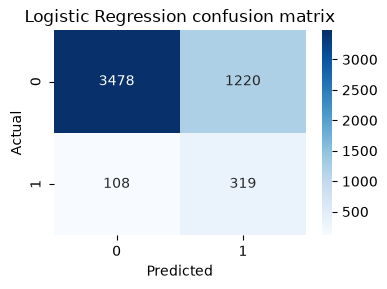

In [36]:
# Logistic Regression - a strong, interpretable linear baseline.
# class_weight='balanced' makes it pay proportionally more attention to the rare wonderkid class.
from sklearn.linear_model import LogisticRegression

logreg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
])
logreg_pipeline.fit(X_train, y_train)
_ = evaluate_model('Logistic Regression', logreg_pipeline)

Random Forest (threshold=0.50)
PR-AUC: 0.298   ROC-AUC: 0.793
positive class -> precision 0.293 | recall 0.482 | F1 0.365 | F2 0.427

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      4698
           1       0.29      0.48      0.36       427

    accuracy                           0.86      5125
   macro avg       0.62      0.69      0.64      5125
weighted avg       0.90      0.86      0.87      5125



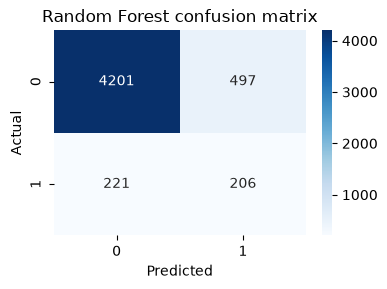

In [37]:
# Random Forest - a bagged ensemble of trees. Handles the mixed feature types and non-linear
# interactions far better than a single tree, and is much less prone to overfitting.
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400, class_weight='balanced_subsample',
        min_samples_leaf=5, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
_ = evaluate_model('Random Forest', rf_pipeline)

HistGradientBoosting (threshold=0.50)
PR-AUC: 0.337   ROC-AUC: 0.811
positive class -> precision 0.210 | recall 0.703 | F1 0.323 | F2 0.478

              precision    recall  f1-score   support

           0       0.97      0.76      0.85      4698
           1       0.21      0.70      0.32       427

    accuracy                           0.75      5125
   macro avg       0.59      0.73      0.59      5125
weighted avg       0.90      0.75      0.81      5125



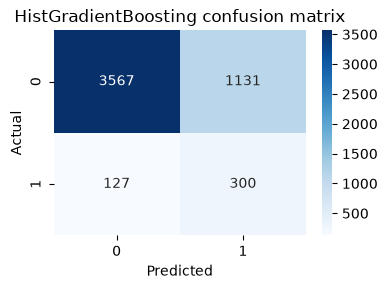

In [38]:
# HistGradientBoosting - sklearn's fast gradient-boosted trees. Often the best "out of the box"
# tabular model. It has no class_weight parameter, so we pass balanced sample weights instead.
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        learning_rate=0.05, max_iter=400, max_depth=None,
        l2_regularization=1.0, random_state=42))
])

sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
hgb_pipeline.fit(X_train, y_train, classifier__sample_weight=sample_weight)
_ = evaluate_model('HistGradientBoosting', hgb_pipeline)

scale_pos_weight = 10.99
XGBoost (threshold=0.50)
PR-AUC: 0.312   ROC-AUC: 0.808
positive class -> precision 0.209 | recall 0.696 | F1 0.321 | F2 0.474

              precision    recall  f1-score   support

           0       0.96      0.76      0.85      4698
           1       0.21      0.70      0.32       427

    accuracy                           0.76      5125
   macro avg       0.59      0.73      0.59      5125
weighted avg       0.90      0.76      0.81      5125



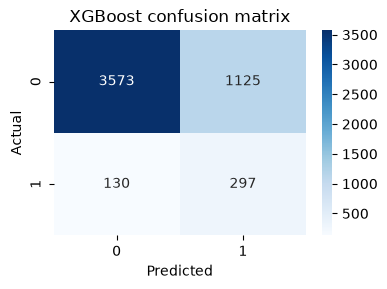

In [39]:
# XGBoost - typically the strongest tabular model. We handle imbalance with scale_pos_weight,
# which is XGBoost's built-in equivalent of class weighting (ratio of negatives to positives).
from xgboost import XGBClassifier

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr', random_state=42, n_jobs=-1))
])
xgb_pipeline.fit(X_train, y_train)
_ = evaluate_model('XGBoost', xgb_pipeline)

XGBoost + SMOTE (threshold=0.50)
PR-AUC: 0.286   ROC-AUC: 0.789
positive class -> precision 0.405 | recall 0.293 | F1 0.340 | F2 0.310

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4698
           1       0.40      0.29      0.34       427

    accuracy                           0.91      5125
   macro avg       0.67      0.63      0.64      5125
weighted avg       0.89      0.91      0.90      5125



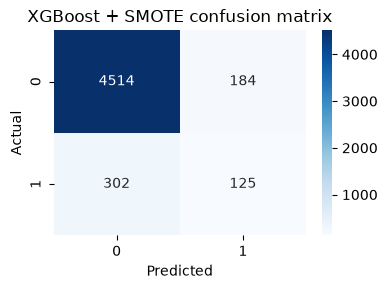

In [40]:
# XGBoost + SMOTE - instead of weighting the minority class, SMOTE synthesises new minority
# examples. We use an imblearn Pipeline so SMOTE is applied ONLY to the training folds during
# cross-validation, never to the validation/test data (a very common leakage mistake otherwise).
# Note: SMOTE runs after the preprocessor, i.e. on the encoded/scaled matrix.
try:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

    smote_xgb_pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9,
            eval_metric='aucpr', random_state=42, n_jobs=-1))
    ])
    smote_xgb_pipeline.fit(X_train, y_train)
    _ = evaluate_model('XGBoost + SMOTE', smote_xgb_pipeline)
except Exception as e:
    print("SMOTE variant skipped:", e)

No-skill PR-AUC baseline (positive rate): 0.083

                      pr_auc  roc_auc  precision  recall     f1     f2
Logistic Regression    0.337    0.808      0.207   0.747  0.325  0.491
HistGradientBoosting   0.337    0.811      0.210   0.703  0.323  0.478
XGBoost                0.312    0.808      0.209   0.696  0.321  0.474
Random Forest          0.298    0.793      0.293   0.482  0.365  0.427
XGBoost + SMOTE        0.286    0.789      0.405   0.293  0.340  0.310


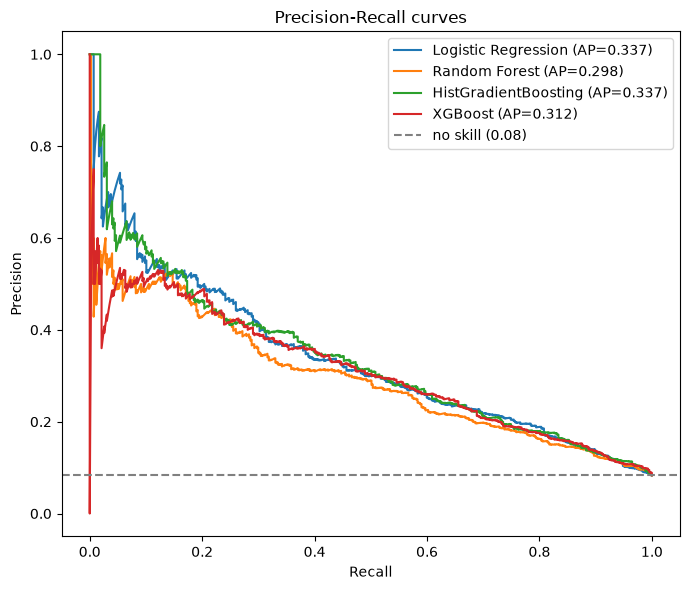

In [41]:
# Compare every model at the default 0.5 threshold. We rank by PR-AUC because it is the most
# informative single number for a rare-positive problem (the no-skill baseline equals the positive
# rate, ~0.15 here, so anything well above that is real signal).
comparison = pd.DataFrame(results).T.sort_values('pr_auc', ascending=False)
print("No-skill PR-AUC baseline (positive rate):", round(y_test.mean(), 3))
print()
print(comparison.round(3))

# Precision-Recall curves for the main candidates.
plt.figure(figsize=(7, 6))
for name, model in [('Logistic Regression', logreg_pipeline),
                    ('Random Forest', rf_pipeline),
                    ('HistGradientBoosting', hgb_pipeline),
                    ('XGBoost', xgb_pipeline)]:
    proba = model.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(rec, prec, label=f'{name} (AP={ap:.3f})')

plt.axhline(y_test.mean(), color='grey', linestyle='--', label=f'no skill ({y_test.mean():.2f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall curves')
plt.legend(); plt.tight_layout(); plt.show()

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'classifier__subsample': 0.7, 'classifier__n_estimators': 400, 'classifier__min_child_weight': 3, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.02, 'classifier__gamma': 1.0, 'classifier__colsample_bytree': 1.0}
Best CV PR-AUC: 0.307
XGBoost (tuned) (threshold=0.50)
PR-AUC: 0.332   ROC-AUC: 0.813
positive class -> precision 0.208 | recall 0.735 | F1 0.324 | F2 0.488

              precision    recall  f1-score   support

           0       0.97      0.75      0.84      4698
           1       0.21      0.74      0.32       427

    accuracy                           0.74      5125
   macro avg       0.59      0.74      0.58      5125
weighted avg       0.91      0.74      0.80      5125



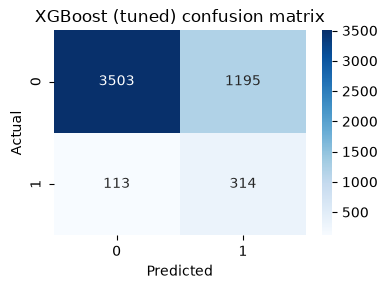

In [42]:
# Hyperparameter tuning on XGBoost (usually our strongest model), scored on PR-AUC via
# stratified 5-fold CV. RandomizedSearchCV samples the grid, which is far cheaper than an
# exhaustive GridSearchCV while finding comparably good settings.
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'classifier__n_estimators': [300, 400, 600, 800],
    'classifier__max_depth': [3, 4, 5, 6],
    'classifier__learning_rate': [0.02, 0.03, 0.05, 0.1],
    'classifier__subsample': [0.7, 0.8, 0.9, 1.0],
    'classifier__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 10],
    'classifier__gamma': [0, 0.5, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    xgb_pipeline, param_distributions=param_dist,
    n_iter=30, scoring='average_precision', cv=cv,
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV PR-AUC: {search.best_score_:.3f}")

best_model = search.best_estimator_
_ = evaluate_model('XGBoost (tuned)', best_model)

F1-optimal threshold (balanced):   0.717  -> precision 0.328 | recall 0.405
F2-optimal threshold (max recall): 0.513  -> precision 0.199 | recall 0.678


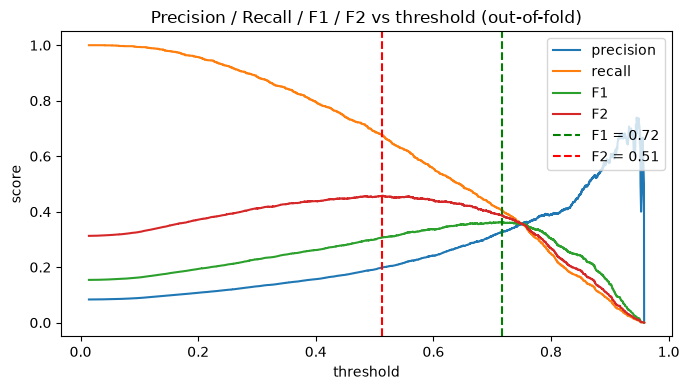

In [43]:
# Threshold tuning. The default 0.5 cut-off is arbitrary for an imbalanced problem and is the main
# reason the roadmap models had such poor recall. We pick the threshold that maximises F2 (recall
# weighted twice as heavily as precision, matching "missing a wonderkid is worse than a false alarm").
#
# Crucially, we choose the threshold from OUT-OF-FOLD predictions on the TRAINING data, not the test
# set, so the test evaluation stays honest.
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(
    best_model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
prec_t, rec_t = prec[:-1], rec[:-1]
f1_scores = (2 * prec_t * rec_t) / (prec_t + rec_t + 1e-9)
f2_scores = (5 * prec_t * rec_t) / (4 * prec_t + rec_t + 1e-9)

# Two useful operating points:
#   F1 threshold  -> balances precision and recall. This is the sensible DEFAULT for the demo/app;
#                    it stops the model flagging almost everyone (the old F2 default did that).
#   F2 threshold  -> weights recall higher: a "scouting net" that catches more real wonderkids at
#                    the cost of more false alarms. Good to show as an alternative.
f1_threshold = float(thr[int(np.nanargmax(f1_scores))])
f2_threshold = float(thr[int(np.nanargmax(f2_scores))])
best_threshold = f2_threshold  # used for the high-recall view in the next cell

f1i, f2i = int(np.nanargmax(f1_scores)), int(np.nanargmax(f2_scores))
print(f"F1-optimal threshold (balanced):   {f1_threshold:.3f}  "
      f"-> precision {prec_t[f1i]:.3f} | recall {rec_t[f1i]:.3f}")
print(f"F2-optimal threshold (max recall): {f2_threshold:.3f}  "
      f"-> precision {prec_t[f2i]:.3f} | recall {rec_t[f2i]:.3f}")

plt.figure(figsize=(7, 4))
plt.plot(thr, prec_t, label='precision')
plt.plot(thr, rec_t, label='recall')
plt.plot(thr, f1_scores, label='F1')
plt.plot(thr, f2_scores, label='F2')
plt.axvline(f1_threshold, color='green', linestyle='--', label=f'F1 = {f1_threshold:.2f}')
plt.axvline(f2_threshold, color='red', linestyle='--', label=f'F2 = {f2_threshold:.2f}')
plt.xlabel('threshold'); plt.ylabel('score')
plt.title('Precision / Recall / F1 / F2 vs threshold (out-of-fold)')
plt.legend(); plt.tight_layout(); plt.show()

Balanced operating point (F1 threshold) - the app default
XGBoost tuned @ F1 threshold (threshold=0.72)
PR-AUC: 0.332   ROC-AUC: 0.813
positive class -> precision 0.356 | recall 0.443 | F1 0.395 | F2 0.422

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      4698
           1       0.36      0.44      0.39       427

    accuracy                           0.89      5125
   macro avg       0.65      0.68      0.67      5125
weighted avg       0.90      0.89      0.89      5125



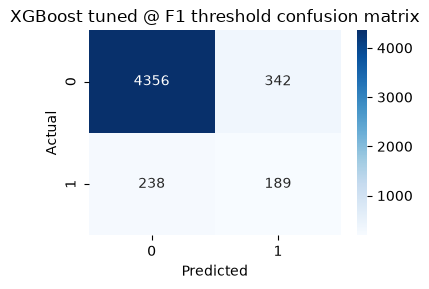

Flagged as wonderkid at F1 threshold: 10.4%  (true base rate: 8.3%)

High-recall scouting net (F2 threshold) - catches more, with more false alarms
XGBoost tuned @ F2 threshold (threshold=0.51)
PR-AUC: 0.332   ROC-AUC: 0.813
positive class -> precision 0.214 | recall 0.719 | F1 0.330 | F2 0.488

              precision    recall  f1-score   support

           0       0.97      0.76      0.85      4698
           1       0.21      0.72      0.33       427

    accuracy                           0.76      5125
   macro avg       0.59      0.74      0.59      5125
weighted avg       0.90      0.76      0.81      5125

Flagged as wonderkid at F2 threshold: 28.0%  (true base rate: 8.3%)


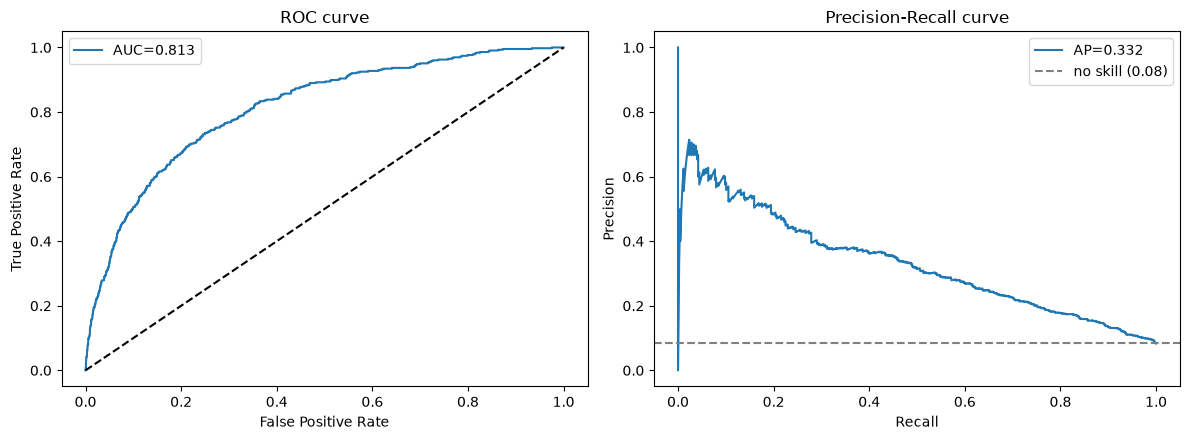

In [44]:
# Final evaluation on the held-out test set, at BOTH operating points so the trade-off is explicit.
# The balanced (F1) point is what the app uses; note how few players it flags vs the base rate.
print("Balanced operating point (F1 threshold) - the app default")
_ = evaluate_model('XGBoost tuned @ F1 threshold', best_model, threshold=f1_threshold, plot_cm=True)
flag_rate_f1 = (best_model.predict_proba(X_test)[:, 1] >= f1_threshold).mean()
print(f"Flagged as wonderkid at F1 threshold: {flag_rate_f1*100:.1f}%  "
      f"(true base rate: {y_test.mean()*100:.1f}%)\n")

print("High-recall scouting net (F2 threshold) - catches more, with more false alarms")
final_proba = evaluate_model('XGBoost tuned @ F2 threshold', best_model,
                             threshold=f2_threshold, plot_cm=False)
flag_rate_f2 = (best_model.predict_proba(X_test)[:, 1] >= f2_threshold).mean()
print(f"Flagged as wonderkid at F2 threshold: {flag_rate_f2*100:.1f}%  "
      f"(true base rate: {y_test.mean()*100:.1f}%)")

# ROC curve alongside the PR curve for completeness.
fpr, tpr, _ = roc_curve(y_test, final_proba)
prec, rec, _ = precision_recall_curve(y_test, final_proba)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, final_proba):.3f}')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlabel('False Positive Rate'); ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('ROC curve'); ax[0].legend()

ax[1].plot(rec, prec, label=f'AP={average_precision_score(y_test, final_proba):.3f}')
ax[1].axhline(y_test.mean(), color='grey', linestyle='--', label=f'no skill ({y_test.mean():.2f})')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall curve'); ax[1].legend()
plt.tight_layout(); plt.show()

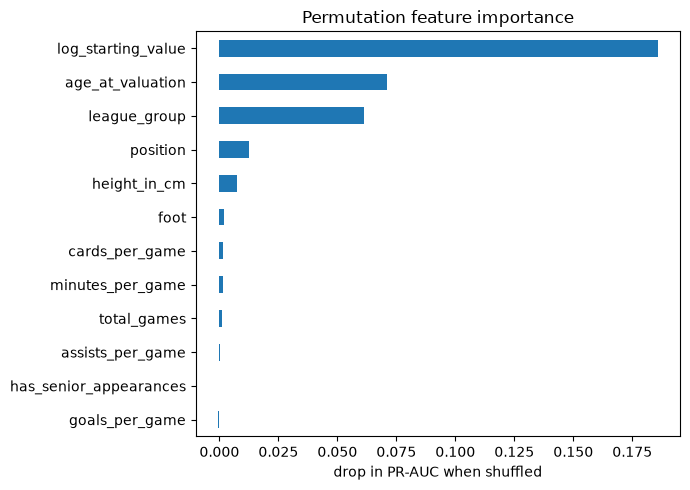

log_starting_value        0.1859
age_at_valuation          0.0711
league_group              0.0612
position                  0.0125
height_in_cm              0.0074
foot                      0.0021
cards_per_game            0.0016
minutes_per_game          0.0014
total_games               0.0012
assists_per_game          0.0001
has_senior_appearances    0.0000
goals_per_game           -0.0007
dtype: float64


In [45]:
# Which signals actually drive the predictions? Permutation importance measures how much PR-AUC
# drops when each feature's values are shuffled - model-agnostic and computed on the test set.
# This is the "here's what the model learned" slide for the presentation.
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_test, y_test,
    scoring='average_precision', n_repeats=10, random_state=42, n_jobs=-1
)
importances = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(7, 5))
importances.plot.barh()
plt.xlabel('drop in PR-AUC when shuffled')
plt.title('Permutation feature importance')
plt.tight_layout(); plt.show()

print(importances.sort_values(ascending=False).round(4))

### SHAP — explainable AI

**Permutation importance** (above) answers: *"Which features matter globally?"* It shuffles each feature and measures how much model quality drops.

**SHAP** answers a sharper question: *"For this specific player, why did the model give them a 0.77 wonderkid probability?"*

Each feature gets a **SHAP value** — how much it pushed the prediction up (red) or down (blue) compared to the model's average prediction. SHAP values add up:

`base rate prediction + sum(SHAP values) = this player's prediction`

That makes the model auditable: you can show a supervisor *"Pedri scored high mostly because of starting market value and league, not because of random noise."*

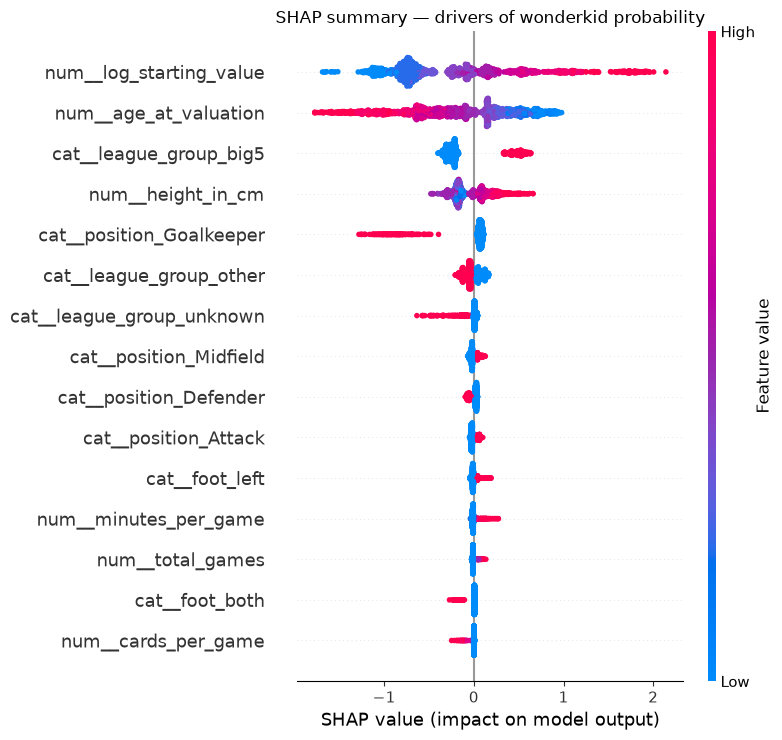

Top features by mean |SHAP|:
num__log_starting_value      0.6391
num__age_at_valuation        0.5257
cat__league_group_big5       0.3165
num__height_in_cm            0.1817
cat__position_Goalkeeper     0.1552
cat__league_group_other      0.0797
cat__league_group_unknown    0.0403
cat__position_Midfield       0.0348
cat__position_Defender       0.0333
cat__position_Attack         0.0310
cat__foot_left               0.0209
num__minutes_per_game        0.0171
dtype: float32


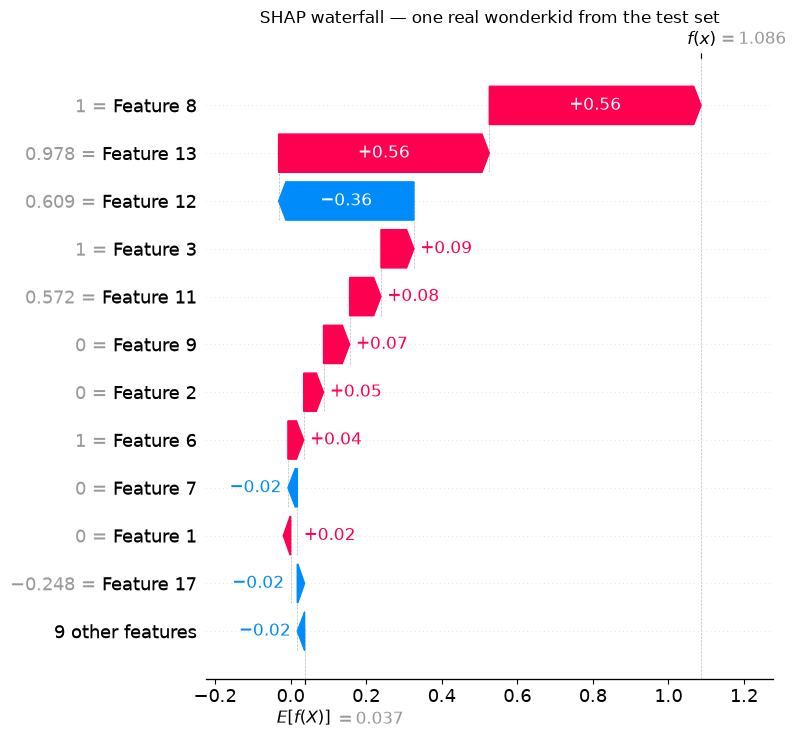

In [46]:
# SHAP on the tuned XGBoost pipeline (before calibration — TreeExplainer needs the tree model).
import shap

xgb_pipe = best_model
prep = xgb_pipe.named_steps['preprocessor']
clf = xgb_pipe.named_steps['classifier']

# Sample test rows — SHAP on the full test set is slow in a notebook.
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=min(1500, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]
X_trans = prep.transform(X_sample)
feature_names = prep.get_feature_names_out()

explainer = shap.TreeExplainer(clf)
shap_explanation = explainer(X_trans)

# Global view: which features push wonderkid probability up/down across many players?
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_explanation, X_trans, feature_names=feature_names,
    show=False, max_display=15,
)
plt.title('SHAP summary — drivers of wonderkid probability')
plt.tight_layout(); plt.show()

mean_abs = pd.Series(
    np.abs(shap_explanation.values).mean(axis=0),
    index=feature_names,
).sort_values(ascending=False)
print('Top features by mean |SHAP|:')
print(mean_abs.round(4).head(12))

# Local view: explain one actual wonderkid from the test sample.
wonderkid_rows = np.where(y_sample.values == 1)[0]
if len(wonderkid_rows):
    idx = wonderkid_rows[0]
    plt.figure(figsize=(8, 5))
    shap.plots.waterfall(shap_explanation[idx], max_display=12, show=False)
    plt.title('SHAP waterfall — one real wonderkid from the test set')
    plt.tight_layout(); plt.show()
else:
    print('No wonderkids in the SHAP sample — re-run or increase sample size.')

Subset size: 2308  |  wonderkid rate: 15.5%
Subset model (real appearance data only) (threshold=0.34)
PR-AUC: 0.530   ROC-AUC: 0.854
positive class -> precision 0.281 | recall 0.887 | F1 0.427 | F2 0.620

              precision    recall  f1-score   support

           0       0.97      0.59      0.73       391
           1       0.28      0.89      0.43        71

    accuracy                           0.63       462
   macro avg       0.62      0.74      0.58       462
weighted avg       0.86      0.63      0.68       462



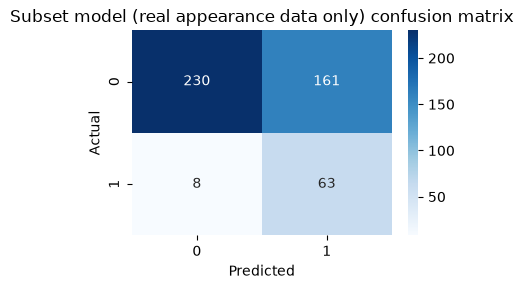

In [47]:
# Subset model: train the SAME tuned pipeline on only the players who actually have real
# appearance data (has_senior_appearances == 1). This answers "how well can we predict when the
# performance features are genuinely present, rather than zero-filled?" - a good honesty check and
# a nice contrast for the presentation.
from sklearn.base import clone

subset = model_df[model_df['has_senior_appearances'] == 1].copy()
Xs = subset.drop('wonderkid', axis=1)
ys = subset['wonderkid']
print(f"Subset size: {len(subset)}  |  wonderkid rate: {ys.mean()*100:.1f}%")

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    Xs, ys, test_size=0.2, random_state=42, stratify=ys)

subset_model = clone(best_model)
subset_model.fit(Xs_tr, ys_tr)

# tune threshold for the subset on its own OOF predictions
oof_s = cross_val_predict(subset_model, Xs_tr, ys_tr, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
p_s, r_s, t_s = precision_recall_curve(ys_tr, oof_s)
f2_s = (5 * p_s[:-1] * r_s[:-1]) / (4 * p_s[:-1] + r_s[:-1] + 1e-9)
subset_threshold = float(t_s[int(np.nanargmax(f2_s))])

_ = evaluate_model('Subset model (real appearance data only)', subset_model,
                   X_te=Xs_te, y_te=ys_te, threshold=subset_threshold, store=False)

## K-Means + PCA - player archetypes

Unsupervised step: cluster young players purely by their early-career profile (ignoring the label),
then check whether wonderkids concentrate in particular archetypes or are spread across all of them.
We use the Elbow method and Silhouette score to choose the number of clusters, and PCA to visualise
the high-dimensional feature space in 2D.

Clustering matrix shape: (25621, 20)


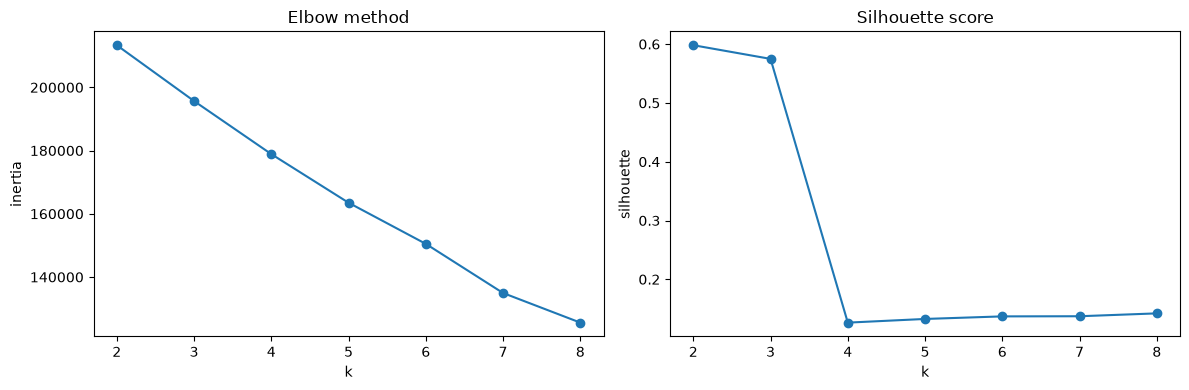

In [48]:
# Transform ALL players with the same preprocessor (unsupervised, so we fit on the full feature set).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_preprocessor = clone(preprocessor)
X_all = cluster_preprocessor.fit_transform(X)
X_all = X_all.toarray() if hasattr(X_all, 'toarray') else np.asarray(X_all)
print("Clustering matrix shape:", X_all.shape)

# Elbow (inertia) + Silhouette to choose k.
Ks = range(2, 9)
inertias, silhouettes = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_all)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_all, km.labels_, sample_size=5000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(Ks), inertias, 'o-'); ax[0].set_xlabel('k'); ax[0].set_ylabel('inertia')
ax[0].set_title('Elbow method')
ax[1].plot(list(Ks), silhouettes, 'o-'); ax[1].set_xlabel('k'); ax[1].set_ylabel('silhouette')
ax[1].set_title('Silhouette score')
plt.tight_layout(); plt.show()

Variance explained by 2 PCA components: [0.271 0.103] -> total 0.374


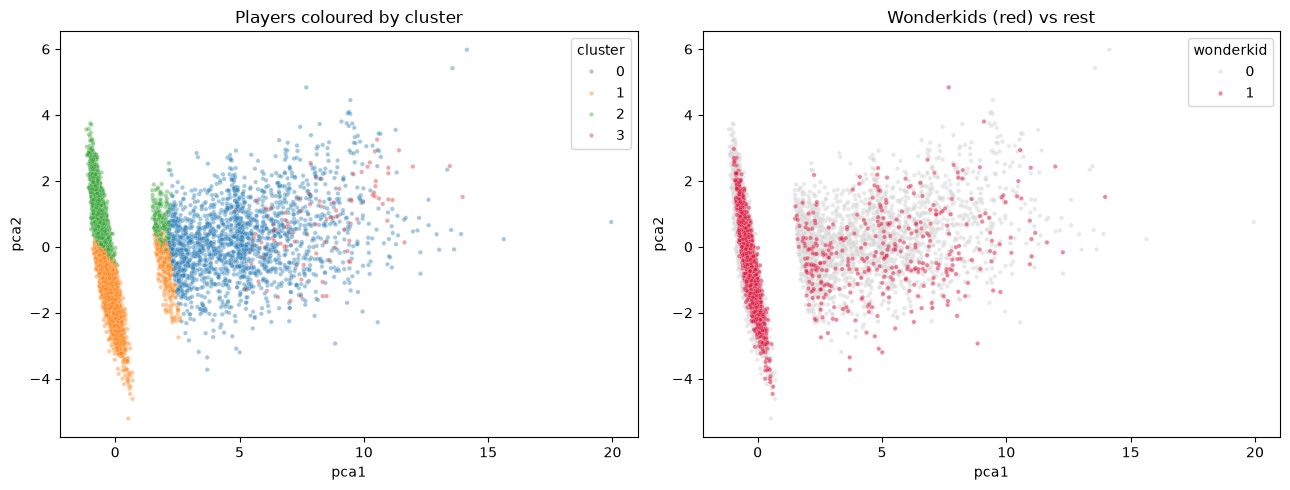

         wonderkid_rate  n_players
cluster                           
0                 0.153       1834
1                 0.089      11520
2                 0.067      12169
3                 0.245         98


In [49]:
# Fit the final K-Means (k=4 is a reasonable, interpretable choice
from sklearn.decomposition import PCA

K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10).fit(X_all)
cluster_labels = kmeans.labels_

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_all)
print("Variance explained by 2 PCA components:", pca.explained_variance_ratio_.round(3),
      "-> total", round(pca.explained_variance_ratio_.sum(), 3))

clustered = X.copy()
clustered['cluster'] = cluster_labels
clustered['wonderkid'] = y.values
clustered['pca1'] = coords[:, 0]
clustered['pca2'] = coords[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=clustered, x='pca1', y='pca2', hue='cluster',
                palette='tab10', s=10, alpha=0.4, ax=ax[0], legend='full')
ax[0].set_title('Players coloured by cluster')
sns.scatterplot(data=clustered.sort_values('wonderkid'), x='pca1', y='pca2',
                hue='wonderkid', palette={0: 'lightgrey', 1: 'crimson'},
                s=10, alpha=0.5, ax=ax[1])
ax[1].set_title('Wonderkids (red) vs rest')
plt.tight_layout(); plt.show()

# Do wonderkids concentrate in particular clusters?
rate = clustered.groupby('cluster')['wonderkid'].agg(['mean', 'count'])
rate.columns = ['wonderkid_rate', 'n_players']
print(rate.round(3))

In [50]:
# Interpret the archetypes: average profile of each cluster on the raw (human-readable) features.
profile_num = clustered.groupby('cluster')[numerical_cols].mean().round(2)
print("Numeric profile per cluster:")
print(profile_num)

print("\nMost common position per cluster:")
print(clustered.groupby('cluster')['position'].agg(lambda s: s.value_counts().index[0]))

print("\nBig-5 league share per cluster:")
print(clustered.assign(is_big5=(clustered['league_group'] == 'big5'))
      .groupby('cluster')['is_big5'].mean().round(3))

Numeric profile per cluster:
         height_in_cm  age_at_valuation  log_starting_value  total_games  \
cluster                                                                    
0              181.23             19.32               12.18         3.93   
1              177.38             19.26               11.79         0.02   
2              186.86             18.64               11.00         0.01   
3              180.03             19.38               12.25         3.22   

         goals_per_game  assists_per_game  minutes_per_game  cards_per_game  \
cluster                                                                       
0                  0.06              0.01             45.54            0.11   
1                  0.00              0.00              0.11            0.00   
2                  0.00              0.00              0.08            0.00   
3                  0.07              0.48             50.69            0.12   

         has_senior_appearances  
clust

## Demo + saving the model

For deployment we retrain the tuned pipeline on ALL labelled players (standard practice once
hyperparameters and the threshold are fixed), then wrap it in a small `predict_wonderkid` helper
and test it on real, recognisable young players pulled straight from the dataset.

In [51]:
# For deployment we do two things differently from the analysis model:
#   1. CALIBRATE the probabilities. Raw XGBoost probs are inflated by class weighting, so an average
#      player could read "60%". Isotonic calibration makes a displayed "30%" mean roughly a 30%
#      chance, which is what makes the app trustworthy and stops it flagging everyone.
#   2. Use the BALANCED (F1) threshold, chosen on out-of-fold CALIBRATED probabilities (no leakage).
from sklearn.calibration import CalibratedClassifierCV

cal_oof = cross_val_predict(
    CalibratedClassifierCV(clone(best_model), method='isotonic', cv=3),
    X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
pc, rc, tc = precision_recall_curve(y_train, cal_oof)
f1c = (2 * pc[:-1] * rc[:-1]) / (pc[:-1] + rc[:-1] + 1e-9)
deploy_threshold = float(tc[int(np.nanargmax(f1c))])

# Retrain the calibrated model on ALL labelled players for deployment.
final_model = CalibratedClassifierCV(clone(best_model), method='isotonic', cv=5)
final_model.fit(X, y)

flagged = (cal_oof >= deploy_threshold).mean()
print(f"Deployment threshold (calibrated, F1): {deploy_threshold:.3f}")
print(f"Flagged as wonderkid at this threshold (out-of-fold): {flagged*100:.1f}%  "
      f"(base rate: {y_train.mean()*100:.1f}%)")

def predict_wonderkid(profile: dict, model=final_model, threshold=deploy_threshold):
    """profile: dict with keys = feature_cols. Returns (calibrated probability, label)."""
    row = pd.DataFrame([profile])[feature_cols]
    proba = float(model.predict_proba(row)[:, 1][0])
    label = 'WONDERKID' if proba >= threshold else 'Not a wonderkid'
    return proba, label

# quick smoke test on a made-up profile
example = {
    'position': 'Attack', 'foot': 'right', 'league_group': 'big5',
    'height_in_cm': 180, 'age_at_valuation': 18.0, 'log_starting_value': np.log1p(3_000_000),
    'total_games': 25, 'goals_per_game': 0.4, 'assists_per_game': 0.2,
    'minutes_per_game': 70, 'cards_per_game': 0.1, 'has_senior_appearances': 1
}
print(predict_wonderkid(example))

Deployment threshold (calibrated, F1): 0.190
Flagged as wonderkid at this threshold (out-of-fold): 10.5%  (base rate: 8.3%)
(0.85, 'WONDERKID')


In [52]:
# The real demo: pull actual players from the dataset by name, feed the model their profile as it
# looked at their first under-21 valuation, and compare the prediction to what actually happened.
name_lookup = players[['player_id', 'name']]
demo_df = final_df.merge(name_lookup, on='player_id', how='left')

def demo_player(search_name):
    hits = demo_df[demo_df['name'].str.contains(search_name, case=False, na=False)]
    if hits.empty:
        print(f"'{search_name}': not found in labelled set (needs an under-21 valuation AND "
              "some age 21-25 data, so very recent teenagers cannot be labelled yet).")
        return
    # A plain name search can match namesakes (e.g. 'Pedri' also matches 'Pedrinho').
    # Pick the most valuable matching player, which is almost always the star we mean.
    row = hits.sort_values('peak_value_21_25', ascending=False).iloc[0]
    profile = {c: row[c] for c in feature_cols}
    proba, label = predict_wonderkid(profile)
    actual = 'WONDERKID' if row['wonderkid'] == 1 else 'not a wonderkid'
    print(f"{row['name']:<22} | age {row['age_at_valuation']:.1f} | "
          f"start EUR {int(row['starting_value']):>10,} | "
          f"model p={proba:.2f} -> {label:<15} | actually {actual}")

print("Known breakout talents:")
for nm in ['Bellingham', 'Pedri', 'Gavi', 'Musiala', 'Wirtz', 'Lamine Yamal', 'Haaland', 'Mbapp']:
    demo_player(nm)

# Sanity check the other direction: ordinary young players should mostly NOT be flagged.
print("\nRandom sample of ordinary young players (should mostly be 'Not a wonderkid'):")
for _, row in demo_df.sample(10, random_state=1).iterrows():
    profile = {c: row[c] for c in feature_cols}
    proba, label = predict_wonderkid(profile)
    actual = 'WONDERKID' if row['wonderkid'] == 1 else 'not a wonderkid'
    print(f"{str(row['name'])[:22]:<22} | start EUR {int(row['starting_value']):>10,} | "
          f"model p={proba:.2f} -> {label:<15} | actually {actual}")

Known breakout talents:


Jude Bellingham        | age 16.3 | start EUR  2,500,000 | model p=0.90 -> WONDERKID       | actually WONDERKID
Pedri                  | age 16.8 | start EUR  5,000,000 | model p=0.95 -> WONDERKID       | actually WONDERKID
Gavi                   | age 17.2 | start EUR 25,000,000 | model p=0.57 -> WONDERKID       | actually not a wonderkid
Jamal Musiala          | age 17.3 | start EUR  1,000,000 | model p=0.77 -> WONDERKID       | actually WONDERKID
Florian Wirtz          | age 17.2 | start EUR 10,000,000 | model p=0.80 -> WONDERKID       | actually WONDERKID
'Lamine Yamal': not found in labelled set (needs an under-21 valuation AND some age 21-25 data, so very recent teenagers cannot be labelled yet).
Erling Haaland         | age 16.4 | start EUR    200,000 | model p=0.28 -> WONDERKID       | actually WONDERKID
Kylian Mbappé          | age 17.0 | start EUR     50,000 | model p=0.11 -> Not a wonderkid | actually WONDERKID

Random sample of ordinary young players (should mostly be 'Not 

In [53]:
# Save the deployable artifact: the fitted pipeline, the tuned threshold, and the metadata the
# Streamlit app needs to build its input widgets. joblib is the standard way to persist sklearn models.
import joblib

bundle = {
    'model': final_model,                 # calibrated, trained on all labelled players
    'explain_model': best_model,          # tuned XGBoost pipeline for SHAP in the app
    'threshold': deploy_threshold,        # balanced F1 threshold
    'base_rate': float(y.mean()),         # share of wonderkids in the data (for context in the app)
    'feature_cols': feature_cols,
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'positions': sorted(model_df['position'].dropna().unique().tolist()),
    'feet': sorted(model_df['foot'].dropna().unique().tolist()),
    'league_groups': sorted(model_df['league_group'].dropna().unique().tolist()),
}
joblib.dump(bundle, 'wonderkid_model.joblib')
print("Saved wonderkid_model.joblib")
print("Deployment threshold:", round(deploy_threshold, 3))
print("Base rate (wonderkid %):", round(bundle['base_rate'] * 100, 1))
print("Features:", feature_cols)

Saved wonderkid_model.joblib
Deployment threshold: 0.19
Base rate (wonderkid %): 8.3
Features: ['position', 'foot', 'league_group', 'height_in_cm', 'age_at_valuation', 'log_starting_value', 'total_games', 'goals_per_game', 'assists_per_game', 'minutes_per_game', 'cards_per_game', 'has_senior_appearances']
